# Задача 9.1 — квазилинеаризация и внутренний погранслой

Рассматривается краевая задача

$$
\varepsilon y'' = y^3 - y,
$$

$$
y(0)=A< -1, \qquad y(1)=B>1.
$$


In [24]:
%run task91_quasilinearization.py
from task91_quasilinearization import *

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True


## 1. Базовый расчёт для одной пары параметров

In [26]:
eps = 1e-2
A = -2.0
B = 2.0

solver, result = solve_problem(
    eps=eps,
    A=A,
    B=B,
    n=2001,
    tol=1e-8,
    max_iter=100,
    damping=0.8,
)

pd.Series(solver.summary(result))


eps                    0.01
A                      -2.0
B                       2.0
n                      2001
iterations               14
converged              True
max_y                   2.0
min_y                  -2.0
layer_thickness    0.397812
dtype: object

In [27]:
layer = solver.compute_layer_thickness(result, level=0.9)
layer


{'level': 0.9,
 'x_left': 0.30109391542138325,
 'x_right': 0.6989060845758217,
 'thickness': 0.39781216915443846}

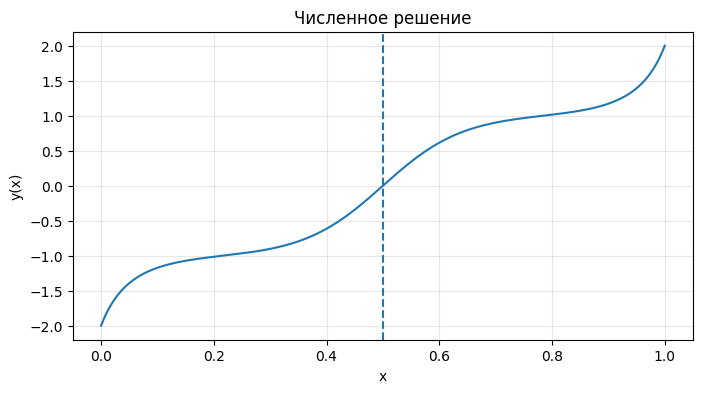

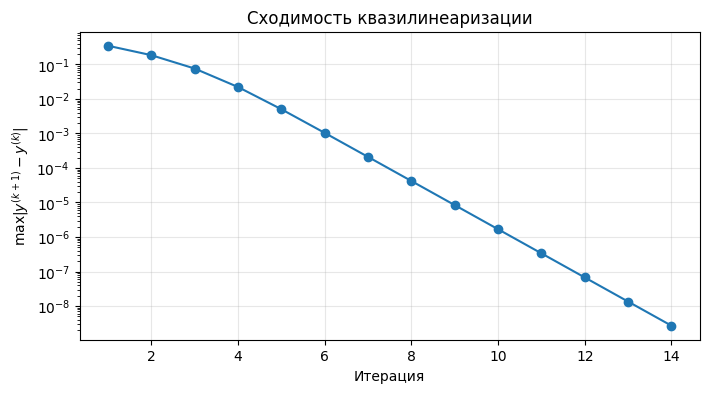

In [28]:
fig, ax = plt.subplots()
solver.plot_solution(result=result, ax=ax)
ax.axvline(0.5, linestyle="--")
ax.set_title("Численное решение")
plt.show()

fig, ax = plt.subplots()
solver.plot_iterations(result=result, ax=ax)
ax.set_title("Сходимость квазилинеаризации")
plt.show()


## 2. Исследование толщины внутреннего слоя в зависимости от $\varepsilon$

Толщину будем определять как расстояние между точками, в которых решение пересекает уровни $-0.9$ и $0.9$:
- $x_-(\varepsilon): y(x_-)=-0.9$,
- $x_+(\varepsilon): y(x_+)=0.9$,

и тогда

$$
\delta(\varepsilon)=x_+(\varepsilon)-x_-(\varepsilon).
$$


In [29]:
eps_values = [2e-2, 1e-2, 5e-3, 2e-3, 1e-3]

df, solutions = study_layer_thickness(
    eps_values=eps_values,
    A=-2.0,
    B=2.0,
    n=2001,
    level=0.9,
    tol=1e-8,
    max_iter=300,
    damping=0.7,
)

df


,eps,iterations,converged,x_left,x_right,thickness
0,0.001,101,True,0.434160,0.565841,0.131681
1,0.002,15,True,0.406889,0.593111,0.186222
2,0.005,15,True,0.353188,0.646812,0.293624
3,0.010,15,True,0.301094,0.698906,0.397812
4,0.020,17,True,0.264817,0.735183,0.470367


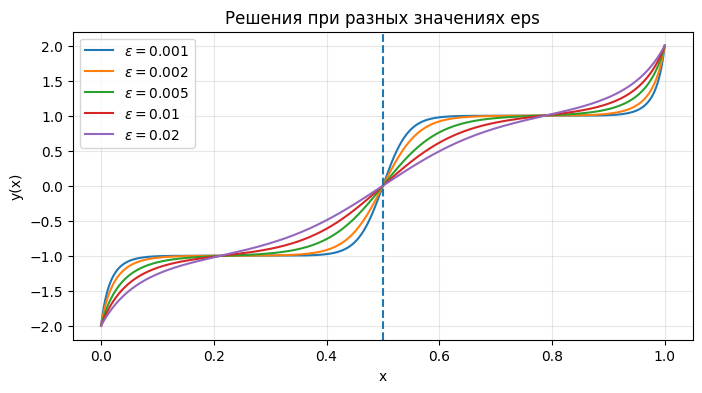

In [30]:
fig, ax = plt.subplots()
for eps in sorted(solutions):
    solver_eps, result_eps = solutions[eps]
    solver_eps.plot_solution(result=result_eps, ax=ax, label=fr"$\varepsilon={eps}$")
ax.axvline(0.5, linestyle="--")
ax.set_title("Решения при разных значениях eps")
plt.show()


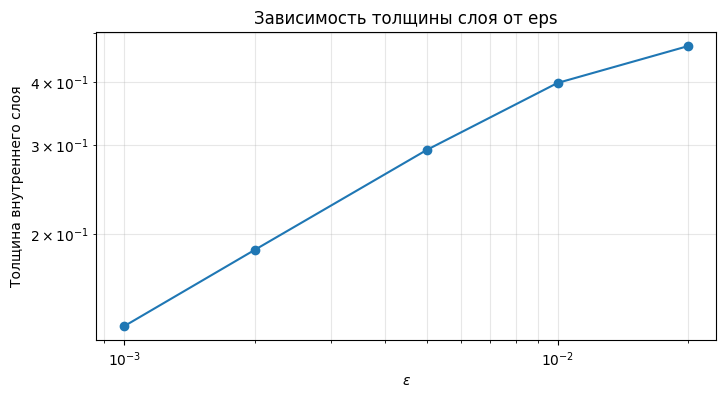

{'power': 0.48245299521671703, 'const': 3.718676471484545}

In [31]:
fig, ax = plt.subplots()
plot_thickness_vs_eps(df, ax=ax)
ax.set_title("Зависимость толщины слоя от eps")
plt.show()

fit_info = fit_power_law(df[df["eps"] <= 1e-2])
fit_info


На малых $\varepsilon$ удобно аппроксимировать зависимость степенным законом

$$
\delta(\varepsilon) \approx C \varepsilon^{\alpha}.
$$

Значение показателя $\alpha$ можно оценить по логарифмической аппроксимации.


## 3. 
Случай $A=0,\;B=0$: три решения

In [32]:
family = solve_zero_boundary_family(
    eps=1e-2,
    n=2001,
    tol=1e-8,
    max_iter=150,
    damping=0.8,
)

summary_rows = []
for name, (solver_i, result_i) in family.items():
    summary_rows.append({
        "solution": name,
        "iterations": result_i.iterations,
        "converged": result_i.converged,
        "y_min": result_i.y.min(),
        "y_max": result_i.y.max(),
    })

pd.DataFrame(summary_rows)


,solution,iterations,converged,y_min,y_max
0,zero,1,True,-0.000000,0.000000
1,plus,12,True,0.000000,0.996597
2,minus,12,True,-0.996597,0.000000


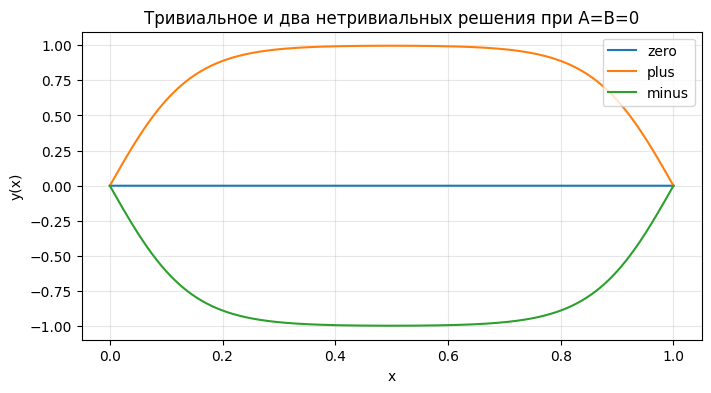

In [33]:
fig, ax = plt.subplots()
plot_zero_boundary_solutions(family, ax=ax)
ax.set_title("Тривиальное и два нетривиальных решения при A=B=0")
plt.show()


Design by OpenAI ChatGPT-5.4 Thinking